# Generacion de Composiciones MIDI: Comparativa entre Modelos LSTM y GRU

## Descripcion del proyecto

Este notebook implementa y compara dos arquitecturas de redes neuronales recurrentes para la generacion automatica de composiciones musicales en formato MIDI: la red de memoria a largo y corto plazo (LSTM) y la unidad recurrente con puertas (GRU).

Ambos modelos se entrenan sobre el mismo corpus de archivos MIDI y se evaluan bajo las mismas condiciones para comparar su rendimiento en terminos de perdida de entrenamiento, velocidad de convergencia y capacidad de generación.

El proceso comprende las siguientes etapas:

1. Preprocesamiento de los archivos MIDI: extraccion y tokenizacion de eventos musicales
2. Construccion del dataset de secuencias para entrenamiento supervisado
3. Definicion de los modelos LSTM y GRU
4. Entrenamiento comparativo
5. Evaluacion y comparacion de resultados
6. Generacion con ambos modelos


---
## Verificacion del entorno de ejecucion

In [1]:
import torch

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Dispositivo de computo: {device}')

if torch.cuda.is_available():
    print(f'GPU:             {torch.cuda.get_device_name(0)}')
    print(f'VRAM disponible: {round(torch.cuda.get_device_properties(0).total_memory / 1e9, 1)} GB')
else:
    print('Advertencia: GPU no detectada. Activar en Entorno de ejecucion > Cambiar tipo de entorno > T4 GPU')

Dispositivo de computo: cuda
GPU:             Tesla T4
VRAM disponible: 15.6 GB


---
## Instalacion de dependencias

In [2]:
!pip install -q music21 matplotlib tqdm
print('Dependencias instaladas correctamente.')

Dependencias instaladas correctamente.


---
## Montaje de Google Drive

Se monta Google Drive para garantizar la persistencia de los checkpoints y resultados entre sesiones.

In [3]:
from google.colab import drive
import os

drive.mount('/content/drive')

SAVE_DIR = '/content/drive/MyDrive/lstm_gru_comparison'
os.makedirs(f'{SAVE_DIR}/lstm', exist_ok=True)
os.makedirs(f'{SAVE_DIR}/gru',  exist_ok=True)

print(f'Directorio de resultados: {SAVE_DIR}')

Mounted at /content/drive
Directorio de resultados: /content/drive/MyDrive/lstm_gru_comparison


---
##Carga de archivos MIDI

Se cargan entre 10 y 15 archivos MIDI que constituyen el corpus de entrenamiento.
A diferencia de la generación con transformers en este proyecto queremos probar si con menos canciones los modelos sencillos son capaces de generalizar mejor artistas de manera individual.
Para eso se han elegido 18 canciones de las bandas Guns N'Roses y Nirvana

In [4]:
from google.colab import files
import os

os.makedirs('/content/midi', exist_ok=True)

print('Cargar archivos MIDI (.mid):')
uploaded = files.upload()
for fname, data in uploaded.items():
    with open(f'/content/midi/{fname}', 'wb') as f:
        f.write(data)

midi_files = sorted([f for f in os.listdir('/content/midi') if f.endswith('.mid')])

print(f'\nArchivos MIDI cargados: {len(midi_files)}')
for f in midi_files:
    print(f'  {f}')


Cargar archivos MIDI (.mid):


Saving BadApples.mid to BadApples.mid
Saving Breed.mid to Breed.mid
Saving ComeAsYouAre.mid to ComeAsYouAre.mid
Saving DrainYou.mid to DrainYou.mid
Saving DustNBones.mid to DustNBones.mid
Saving InBloom.mid to InBloom.mid
Saving ItsSoEasy.mid to ItsSoEasy.mid
Saving KnockingOnHeavensDoor.mid to KnockingOnHeavensDoor.mid
Saving Lithium.mid to Lithium.mid
Saving LoungeAct.mid to LoungeAct.mid
Saving MyMichelle.mid to MyMichelle.mid
Saving OutTaGetMe.mid to OutTaGetMe.mid
Saving ParadiseCity.mid to ParadiseCity.mid
Saving Polly.mid to Polly.mid
Saving SmellsLikeTeenSpirit.mid to SmellsLikeTeenSpirit.mid
Saving SweetChildOfMine.mid to SweetChildOfMine.mid
Saving ThinkAboutYou.mid to ThinkAboutYou.mid
Saving WelcomeToTheJungle.mid to WelcomeToTheJungle.mid

Archivos MIDI cargados: 18
  BadApples.mid
  Breed.mid
  ComeAsYouAre.mid
  DrainYou.mid
  DustNBones.mid
  InBloom.mid
  ItsSoEasy.mid
  KnockingOnHeavensDoor.mid
  Lithium.mid
  LoungeAct.mid
  MyMichelle.mid
  OutTaGetMe.mid
  Paradis

---
## Preprocesamiento: extraccion y tokenizacion de eventos MIDI

Los archivos MIDI se parsean con music21 para extraer los eventos musicales: notas individuales y acordes. Cada evento se tokenizan


In [5]:
from music21 import converter, note, chord, stream
import numpy as np
from tqdm import tqdm

def extract_events(midi_path):
    """
    Extrae los eventos musicales de un archivo MIDI.

    Devuelve una lista de tuplas (token, duracion) donde token es la
    representacion textual de la nota o acorde y duracion es su longitud
    en unidades de quarter note.
    """
    events = []
    try:
        midi  = converter.parse(midi_path)
        parts = midi.getElementsByClass(stream.Part)
        track = parts[0] if parts else midi

        for element in track.flat.notes:
            duration = round(float(element.duration.quarterLength), 2)
            if isinstance(element, note.Note):
                events.append((str(element.pitch), duration))
            elif isinstance(element, chord.Chord):
                token = '.'.join(str(p) for p in sorted(element.pitches, key=lambda p: p.midi))
                events.append((token, duration))
    except Exception as e:
        print(f'Error procesando {midi_path}: {e}')
    return events


all_events = []
print('Extrayendo eventos MIDI...')
for fname in tqdm(midi_files):
    events = extract_events(f'/content/midi/{fname}')
    all_events.extend(events)
    print(f'  {fname}: {len(events)} eventos')

all_tokens    = [e[0] for e in all_events]
all_durations = [e[1] for e in all_events]

print(f'\nTotal de eventos extraidos: {len(all_events)}')

Extrayendo eventos MIDI...


  0%|          | 0/18 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/music21/stream/base.py:3675: Music21DeprecationWarning: .flat is deprecated.  Call .flatten() instead
  return self.iter().getElementsByClass(classFilterList)
  6%|▌         | 1/18 [00:03<01:06,  3.94s/it]

  BadApples.mid: 561 eventos


 11%|█         | 2/18 [00:06<00:46,  2.88s/it]

  Breed.mid: 745 eventos


...

  SweetChildOfMine.mid: 356 eventos


 94%|█████████▍| 17/18 [00:51<00:04,  4.10s/it]

  ThinkAboutYou.mid: 809 eventos


100%|██████████| 18/18 [00:55<00:00,  3.11s/it]

  WelcomeToTheJungle.mid: 974 eventos

Total de eventos extraidos: 11315


### Construccion del vocabulario

Se construyen los vocabularios de tokens y duraciones a partir del corpus completo. Cada elemento unico se mapea a un indice entero para su procesamiento por las redes neuronales.

In [6]:
# Vocabulario de tokens de notas y acordes
unique_tokens    = sorted(set(all_tokens))
token_to_idx     = {t: i for i, t in enumerate(unique_tokens)}
idx_to_token     = {i: t for t, i in token_to_idx.items()}
vocab_size       = len(unique_tokens)

# Vocabulario de duraciones
unique_durations = sorted(set(all_durations))
dur_to_idx       = {d: i for i, d in enumerate(unique_durations)}
idx_to_dur       = {i: d for d, i in dur_to_idx.items()}
dur_vocab_size   = len(unique_durations)

# Convertir secuencias a indices
token_seq = [token_to_idx[t] for t in all_tokens]
dur_seq   = [dur_to_idx[d]   for d in all_durations]

print(f'Tamano del vocabulario de tokens:     {vocab_size}')
print(f'Tamano del vocabulario de duraciones: {dur_vocab_size}')
print(f'Total de eventos en la secuencia:     {len(token_seq)}')

Tamano del vocabulario de tokens:     373
Tamano del vocabulario de duraciones: 30
Total de eventos en la secuencia:     11315


---
## Construccion del dataset de entrenamiento

Se construye el dataset mediante  ventana deslizante.

In [7]:
import torch
from torch.utils.data import Dataset, DataLoader

SEQ_LEN = 64

class MidiDataset(Dataset):
    """
    Dataset de secuencias MIDI para entrenamiento de modelos recurrentes.

    Cada muestra consiste en una ventana de SEQ_LEN eventos consecutivos
    como entrada y el evento siguiente como objetivo de prediccion.
    """

    def __init__(self, token_seq, dur_seq, seq_len):
        self.token_seq = token_seq
        self.dur_seq   = dur_seq
        self.seq_len   = seq_len

    def __len__(self):
        return len(self.token_seq) - self.seq_len

    def __getitem__(self, idx):
        x_token = torch.tensor(self.token_seq[idx:idx + self.seq_len],        dtype=torch.long)
        x_dur   = torch.tensor(self.dur_seq[idx:idx + self.seq_len],           dtype=torch.long)
        y_token = torch.tensor(self.token_seq[idx + 1:idx + self.seq_len + 1], dtype=torch.long)
        y_dur   = torch.tensor(self.dur_seq[idx + 1:idx + self.seq_len + 1],   dtype=torch.long)
        return x_token, x_dur, y_token, y_dur


dataset    = MidiDataset(token_seq, dur_seq, SEQ_LEN)
val_size   = max(1, int(len(dataset) * 0.1))
train_size = len(dataset) - val_size
train_set, val_set = torch.utils.data.random_split(
    dataset, [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_set, batch_size=64, shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_set,   batch_size=64, shuffle=False, num_workers=0, pin_memory=True)

print(f'Muestras de entrenamiento: {train_size}')
print(f'Muestras de validacion:    {val_size}')
print(f'Longitud de ventana:       {SEQ_LEN} eventos')

Muestras de entrenamiento: 10126
Muestras de validacion:    1125
Longitud de ventana:       64 eventos


---
## Definicion de los modelos LSTM y GRU

Se definen ambos modelos con una arquitectura equivalente para garantizar la comparabilidad.

In [8]:
import torch
import torch.nn as nn


class MidiRNN(nn.Module):
    """
    Red neuronal recurrente para generacion de secuencias MIDI.

    Soporta tanto LSTM como GRU mediante el parametro rnn_type,
    permitiendo la comparacion directa entre ambas arquitecturas
    bajo condiciones identicas.

    Parametros:
        vocab_size:     tamano del vocabulario de tokens de notas/acordes
        dur_vocab_size: tamano del vocabulario de duraciones
        embed_dim:      dimension de los embeddings de entrada
        hidden_dim:     dimension del estado oculto de las celdas recurrentes
        num_layers:     numero de capas recurrentes apiladas
        dropout:        tasa de dropout entre capas recurrentes
        rnn_type:       tipo de celda recurrente ('LSTM' o 'GRU')
    """

    def __init__(self, vocab_size, dur_vocab_size, embed_dim=128,
                 hidden_dim=256, num_layers=3, dropout=0.3, rnn_type='LSTM'):
        super().__init__()

        self.rnn_type   = rnn_type
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        # Embeddings de tokens y duraciones
        self.token_emb = nn.Embedding(vocab_size,     embed_dim)
        self.dur_emb   = nn.Embedding(dur_vocab_size, embed_dim)

        # Capa recurrente: LSTM o GRU segun rnn_type
        rnn_class  = nn.LSTM if rnn_type == 'LSTM' else nn.GRU
        self.rnn   = rnn_class(
            input_size  = embed_dim * 2,  # concatenacion de token + duracion
            hidden_size = hidden_dim,
            num_layers  = num_layers,
            dropout     = dropout if num_layers > 1 else 0.0,
            batch_first = True
        )

        # Regularizacion
        self.dropout = nn.Dropout(dropout)

        # Cabezas de prediccion
        self.token_head = nn.Linear(hidden_dim, vocab_size)
        self.dur_head   = nn.Linear(hidden_dim, dur_vocab_size)

    def forward(self, x_token, x_dur, hidden=None):
        # Concatenar embeddings de tokens y duraciones
        x = torch.cat([self.token_emb(x_token), self.dur_emb(x_dur)], dim=-1)

        # Paso por la capa recurrente
        out, hidden = self.rnn(x, hidden)
        out = self.dropout(out)

        return self.token_head(out), self.dur_head(out), hidden


# Instanciar ambos modelos con arquitectura equivalente
MODEL_PARAMS = dict(
    vocab_size     = vocab_size,
    dur_vocab_size = dur_vocab_size,
    embed_dim      = 128,
    hidden_dim     = 256,
    num_layers     = 3,
    dropout        = 0.3
)

lstm_model = MidiRNN(**MODEL_PARAMS, rnn_type='LSTM').to(device)
gru_model  = MidiRNN(**MODEL_PARAMS, rnn_type='GRU').to(device)

lstm_params = sum(p.numel() for p in lstm_model.parameters())
gru_params  = sum(p.numel() for p in gru_model.parameters())

print(f'Parametros LSTM: {lstm_params:,} ({lstm_params/1e6:.2f}M)')
print(f'Parametros GRU:  {gru_params:,}  ({gru_params/1e6:.2f}M)')
print(f'Diferencia:      {(1 - gru_params/lstm_params)*100:.1f}% menos parametros en GRU')

Parametros LSTM: 1,734,163 (1.73M)
Parametros GRU:  1,339,411  (1.34M)
Diferencia:      22.8% menos parametros en GRU


---
## Entrenamiento comparativo

Ambos modelos se entrenan de forma secuencial bajo las mismas condiciones: mismo numero de epochs, mismo optimizador, mismo scheduler y mismo criterio de perdida. Se registran las curvas de perdida de ambos modelos para su comparacion posterior.


In [9]:
import torch.optim as optim
import time
from glob import glob

# Hiperparametros de entrenamiento
EPOCHS     = 100
LR         = 1e-3
SAVE_EVERY = 20

criterion  = nn.CrossEntropyLoss()


def train_model(model, model_name, train_loader, val_loader,
                epochs, lr, save_dir, save_every, device):
    """
    Entrena un modelo recurrente y registra las metricas de entrenamiento.

    Parametros:
        model:        modelo MidiRNN a entrenar (LSTM o GRU)
        model_name:   nombre identificador del modelo para logs y checkpoints
        train_loader: DataLoader del conjunto de entrenamiento
        val_loader:   DataLoader del conjunto de validacion
        epochs:       numero total de epochs
        lr:           learning rate inicial
        save_dir:     directorio de guardado de checkpoints en Drive
        save_every:   frecuencia de guardado en epochs
        device:       dispositivo de computo (cuda o cpu)

    Devuelve:
        Diccionario con las listas de perdida de entrenamiento y validacion
        y el tiempo total de entrenamiento en segundos.
    """
    optimizer    = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-2)
    scheduler    = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    train_losses = []
    val_losses   = []
    start_epoch  = 0

    # Recuperar checkpoint si existe
    checkpoints = sorted(glob(f'{save_dir}/checkpoint_epoch*.pt'))
    if checkpoints:
        ckpt = torch.load(checkpoints[-1], map_location=device)
        model.load_state_dict(ckpt['model'])
        optimizer.load_state_dict(ckpt['optimizer'])
        scheduler.load_state_dict(ckpt['scheduler'])
        start_epoch  = ckpt['epoch'] + 1
        train_losses = ckpt.get('train_losses', [])
        val_losses   = ckpt.get('val_losses', [])
        print(f'[{model_name}] Reanudando desde epoch {start_epoch}')
    else:
        print(f'[{model_name}] Iniciando entrenamiento desde cero.')

    t_start = time.time()

    for epoch in range(start_epoch, epochs):
        # Fase de entrenamiento
        model.train()
        train_loss = 0.0
        for x_token, x_dur, y_token, y_dur in train_loader:
            x_token, x_dur = x_token.to(device), x_dur.to(device)
            y_token, y_dur = y_token.to(device), y_dur.to(device)

            optimizer.zero_grad()
            pred_token, pred_dur, _ = model(x_token, x_dur)
            loss = (
                criterion(pred_token.reshape(-1, vocab_size),   y_token.reshape(-1)) +
                criterion(pred_dur.reshape(-1, dur_vocab_size), y_dur.reshape(-1))
            )
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            train_loss += loss.item()
        train_loss /= len(train_loader)

        # Fase de validacion
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for x_token, x_dur, y_token, y_dur in val_loader:
                x_token, x_dur = x_token.to(device), x_dur.to(device)
                y_token, y_dur = y_token.to(device), y_dur.to(device)
                pred_token, pred_dur, _ = model(x_token, x_dur)
                val_loss += (
                    criterion(pred_token.reshape(-1, vocab_size),   y_token.reshape(-1)) +
                    criterion(pred_dur.reshape(-1, dur_vocab_size), y_dur.reshape(-1))
                ).item()
        val_loss /= len(val_loader)

        scheduler.step()
        train_losses.append(train_loss)
        val_losses.append(val_loss)

        if (epoch + 1) % 10 == 0:
            elapsed = time.time() - t_start
            print(f'[{model_name}] Epoch {epoch+1:4d}/{epochs} | '
                  f'Train: {train_loss:.4f} | '
                  f'Val: {val_loss:.4f} | '
                  f'LR: {scheduler.get_last_lr()[0]:.2e} | '
                  f'Tiempo: {elapsed:.0f}s')

        if (epoch + 1) % save_every == 0:
            ckpt_path = f'{save_dir}/checkpoint_epoch{epoch+1:04d}.pt'
            torch.save({
                'epoch':        epoch,
                'model':        model.state_dict(),
                'optimizer':    optimizer.state_dict(),
                'scheduler':    scheduler.state_dict(),
                'train_losses': train_losses,
                'val_losses':   val_losses,
            }, ckpt_path)
            print(f'  [{model_name}] Checkpoint guardado: {ckpt_path}')

    total_time = time.time() - t_start

    # Guardar modelo final
    torch.save({
        'model': model.state_dict(),
        'vocab': {
            'token_to_idx':   token_to_idx,
            'idx_to_token':   idx_to_token,
            'dur_to_idx':     dur_to_idx,
            'idx_to_dur':     idx_to_dur,
            'vocab_size':     vocab_size,
            'dur_vocab_size': dur_vocab_size,
        }
    }, f'{save_dir}/model_final.pt')

    print(f'\n[{model_name}] Entrenamiento completado en {total_time:.0f}s ({total_time/60:.1f} min)')
    return {'train': train_losses, 'val': val_losses, 'time': total_time}


# Entrenar LSTM
print('=' * 60)
print('ENTRENAMIENTO LSTM')
print('=' * 60)
lstm_results = train_model(
    lstm_model, 'LSTM', train_loader, val_loader,
    EPOCHS, LR, f'{SAVE_DIR}/lstm', SAVE_EVERY, device
)

# Entrenar GRU
print('\n' + '=' * 60)
print('ENTRENAMIENTO GRU')
print('=' * 60)
gru_results = train_model(
    gru_model, 'GRU', train_loader, val_loader,
    EPOCHS, LR, f'{SAVE_DIR}/gru', SAVE_EVERY, device
)

ENTRENAMIENTO LSTM
[LSTM] Iniciando entrenamiento desde cero.
[LSTM] Epoch   10/100 | Train: 0.2405 | Val: 0.1521 | LR: 9.76e-04 | Tiempo: 35s
[LSTM] Epoch   20/100 | Train: 0.1508 | Val: 0.1235 | LR: 9.05e-04 | Tiempo: 72s
  [LSTM] Checkpoint guardado: /content/drive/MyDrive/lstm_gru_comparison/lstm/checkpoint_epoch0020.pt
[LSTM] Epoch   30/100 | Train: 0.1261 | Val: 0.1148 | LR: 7.94e-04 | Tiempo: 113s
[LSTM] Epoch   40/100 | Train: 0.1135 | Val: 0.1096 | LR: 6.55e-04 | Tiempo: 154s
  [LSTM] Checkpoint guardado: /content/drive/MyDrive/lstm_gru_comparison/lstm/checkpoint_epoch0040.pt
[LSTM] Epoch   50/100 | Train: 0.1040 | Val: 0.1078 | LR: 5.00e-04 | Tiempo: 194s
[LSTM] Epoch   60/100 | Train: 0.0979 | Val: 0.1053 | LR: 3.45e-04 | Tiempo: 235s
  [LSTM] Checkpoint guardado: /content/drive/MyDrive/lstm_gru_comparison/lstm/checkpoint_epoch0060.pt
[LSTM] Epoch   70/100 | Train: 0.0940 | Val: 0.1044 | LR: 2.06e-04 | Tiempo: 275s
[LSTM] Epoch   80/100 | Train: 0.0911 | Val: 0.1044 | LR: 9.

---
## Comparacion de resultados

Se comparan las curvas de convergencia de ambos modelos y se resumen las metricas clave: perdida final de entrenamiento y validacion, tiempo de entrenamiento y numero de parametros.

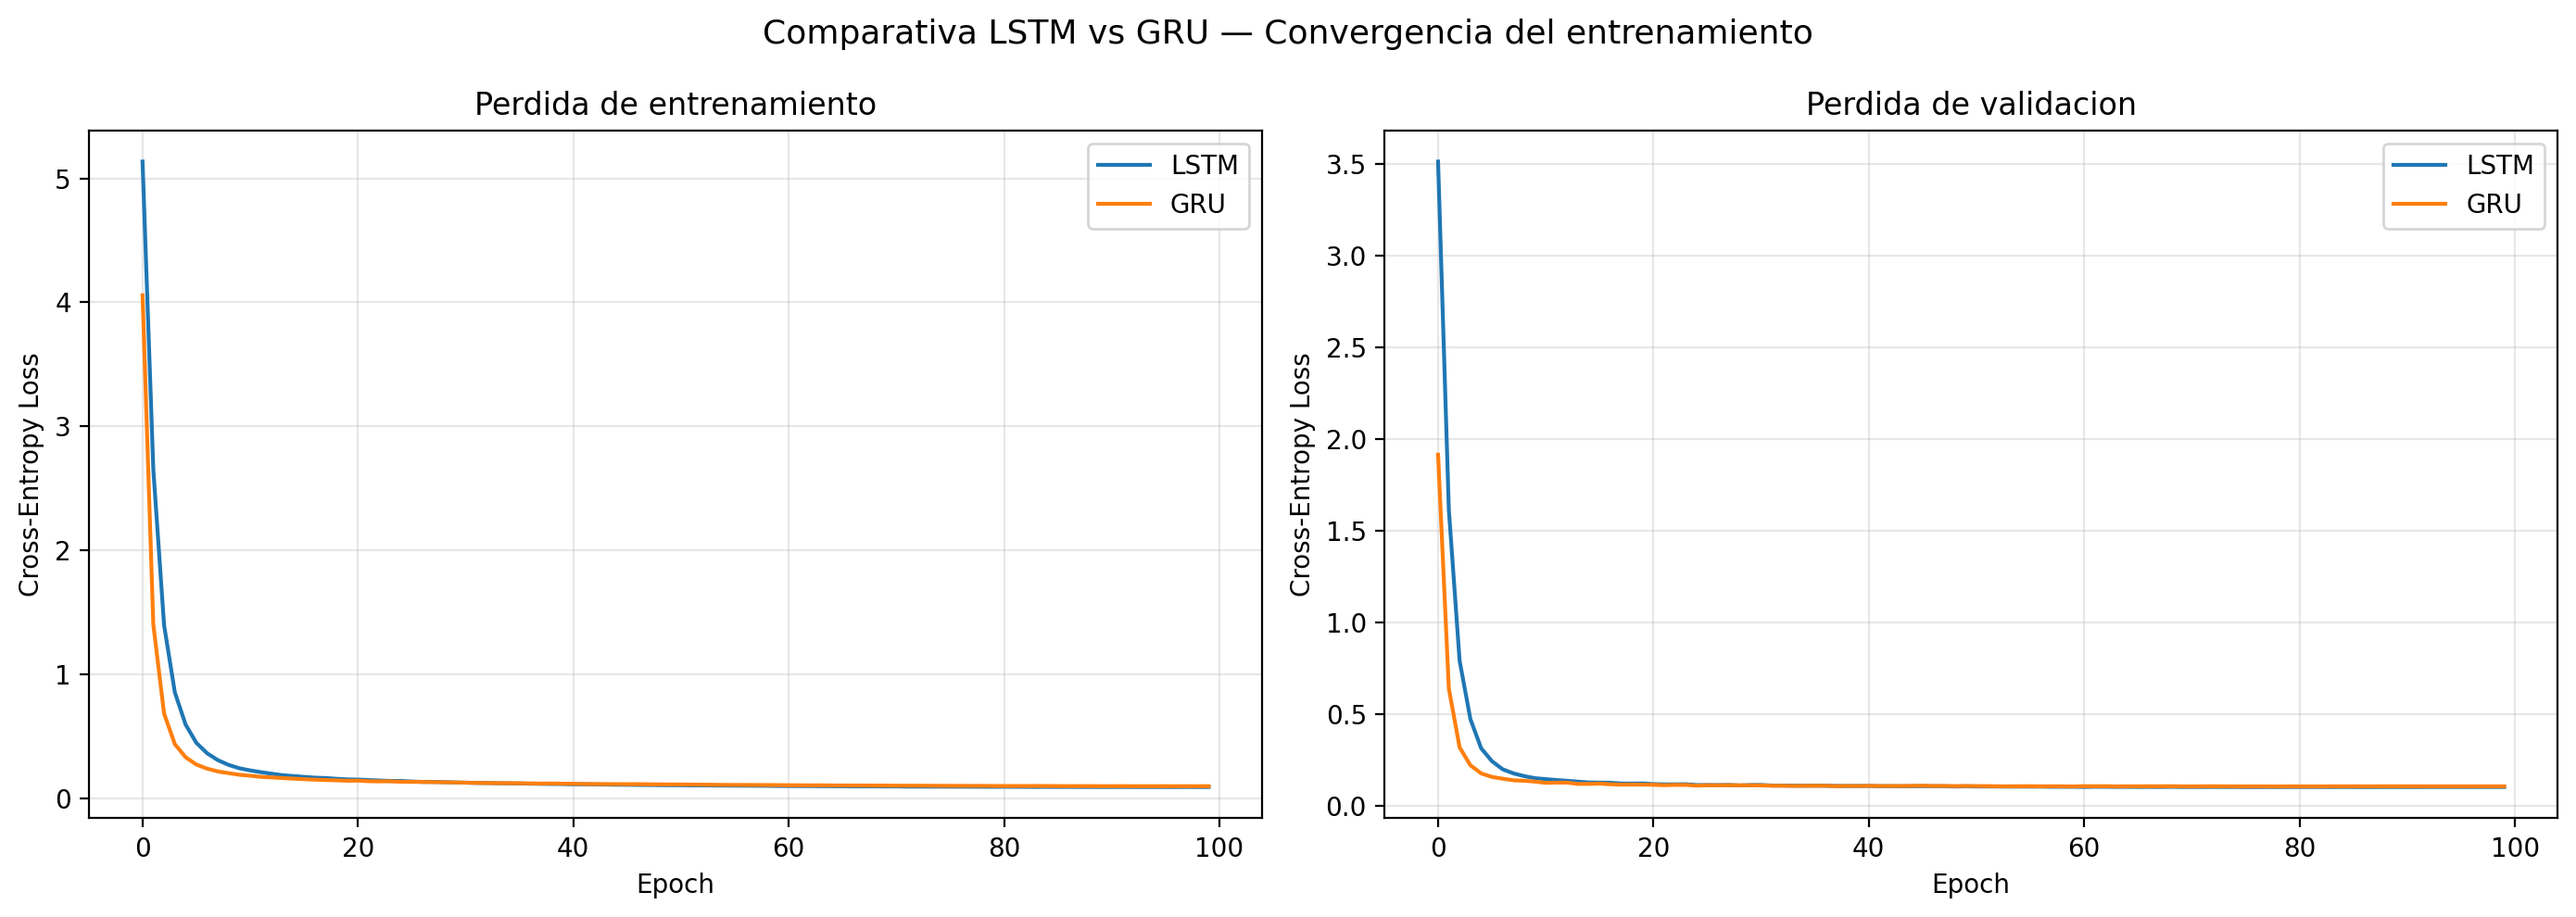


Resumen comparativo:
Metrica                                     LSTM          GRU
------------------------------------------------------------
Parametros                             1,734,163    1,339,411
Loss train final                          0.0896       0.0960
Loss val final                            0.1042       0.1075
Tiempo de entrenamiento (s)                  396          334
Tiempo de entrenamiento (min)                6.6          5.6


In [10]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Curvas de perdida de entrenamiento
axes[0].plot(lstm_results['train'], label='LSTM', linewidth=1.5)
axes[0].plot(gru_results['train'],  label='GRU',  linewidth=1.5)
axes[0].set_title('Perdida de entrenamiento')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Curvas de perdida de validacion
axes[1].plot(lstm_results['val'], label='LSTM', linewidth=1.5)
axes[1].plot(gru_results['val'],  label='GRU',  linewidth=1.5)
axes[1].set_title('Perdida de validacion')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Cross-Entropy Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Comparativa LSTM vs GRU — Convergencia del entrenamiento', fontsize=13)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/comparison_curves.png', dpi=150)
plt.show()

# Tabla resumen
print('\nResumen comparativo:')
print(f'{"Metrica":<35} {"LSTM":>12} {"GRU":>12}')
print('-' * 60)
print(f'{"Parametros":<35} {lstm_params:>12,} {gru_params:>12,}')
print(f'{"Loss train final":<35} {lstm_results["train"][-1]:>12.4f} {gru_results["train"][-1]:>12.4f}')
print(f'{"Loss val final":<35} {lstm_results["val"][-1]:>12.4f} {gru_results["val"][-1]:>12.4f}')
print(f'{"Tiempo de entrenamiento (s)":<35} {lstm_results["time"]:>12.0f} {gru_results["time"]:>12.0f}')
print(f'{"Tiempo de entrenamiento (min)":<35} {lstm_results["time"]/60:>12.1f} {gru_results["time"]/60:>12.1f}')

Se puede ver que el modelo de GRU tarda menos en converger y que tiene menos perdidas, esto era lo esperable ya que tiene menos parametros

---
## Generacion de composiciones MIDI

Se generan nuevas canciones con ambos modelos.

In [11]:
import torch.nn.functional as F
import random

def generate_events(model, token_seq, dur_seq, n_events=256,
                    temperature=0.9, seq_len=64):
    """
    Genera una secuencia de eventos MIDI mediante muestreo autoregresivo.

    Parametros:
        model:       modelo MidiRNN entrenado
        token_seq:   secuencia de indices de tokens del corpus
        dur_seq:     secuencia de indices de duraciones del corpus
        n_events:    numero de eventos a generar
        temperature: factor de escala de los logits
        seq_len:     longitud de la ventana de contexto

    Devuelve:
        Lista de tuplas (token_str, duracion_float)
    """
    model.eval()
    start      = random.randint(0, len(token_seq) - seq_len - 1)
    ctx_tokens = list(token_seq[start:start + seq_len])
    ctx_durs   = list(dur_seq[start:start + seq_len])
    generated  = []
    hidden     = None

    for _ in range(n_events):
        x_t = torch.tensor([ctx_tokens[-seq_len:]], dtype=torch.long).to(device)
        x_d = torch.tensor([ctx_durs[-seq_len:]],   dtype=torch.long).to(device)

        with torch.no_grad():
            pred_t, pred_d, hidden = model(x_t, x_d, hidden)

        logits_t = pred_t[0, -1] / temperature
        logits_d = pred_d[0, -1] / temperature
        next_t   = torch.multinomial(F.softmax(logits_t, dim=-1), 1).item()
        next_d   = torch.multinomial(F.softmax(logits_d, dim=-1), 1).item()

        ctx_tokens.append(next_t)
        ctx_durs.append(next_d)
        generated.append((idx_to_token[next_t], idx_to_dur[next_d]))

        # Reiniciar el estado oculto para evitar acumulacion de gradientes
        if isinstance(hidden, tuple):
            hidden = tuple(h.detach() for h in hidden)
        else:
            hidden = hidden.detach()

    return generated


print('Generando composicion con LSTM...')
lstm_events = generate_events(lstm_model, token_seq, dur_seq, n_events=256, temperature=0.9)
print(f'Eventos generados por LSTM: {len(lstm_events)}')

print('\nGenerando composicion con GRU...')
gru_events  = generate_events(gru_model,  token_seq, dur_seq, n_events=256, temperature=0.9)
print(f'Eventos generados por GRU:  {len(gru_events)}')

Generando composicion con LSTM...
Eventos generados por LSTM: 256

Generando composicion con GRU...
Eventos generados por GRU:  256


---
## Conversion de eventos a archivos MIDI

Las secuencias de eventos generadas por ambos modelos se convierten a archivos MIDI mediante music21 para su escucha y evaluacion auditiva.

In [12]:
from music21 import stream, note, chord, duration
import os

os.makedirs('/content/generated', exist_ok=True)

def events_to_midi(events, output_path):
    """
    Convierte una lista de eventos (token, duracion) a un archivo MIDI.

    Parametros:
        events:      lista de tuplas (token_str, duracion_float)
        output_path: ruta del archivo MIDI de salida
    """
    output_stream = stream.Stream()

    for token_str, dur_val in events:
        dur_obj = duration.Duration(quarterLength=float(dur_val))
        if '.' in token_str:
            try:
                c = chord.Chord(token_str.split('.'), duration=dur_obj)
                output_stream.append(c)
            except Exception:
                pass
        else:
            try:
                n = note.Note(token_str, duration=dur_obj)
                output_stream.append(n)
            except Exception:
                pass

    output_stream.write('midi', fp=output_path)


LSTM_MIDI = '/content/generated/composition_lstm.mid'
GRU_MIDI  = '/content/generated/composition_gru.mid'

events_to_midi(lstm_events, LSTM_MIDI)
events_to_midi(gru_events,  GRU_MIDI)

print(f'MIDI generado por LSTM: {LSTM_MIDI}')
print(f'MIDI generado por GRU:  {GRU_MIDI}')

MIDI generado por LSTM: /content/generated/composition_lstm.mid
MIDI generado por GRU:  /content/generated/composition_gru.mid


Vamos a usar el fluidsynth para escuchar las canciones como .wav (en colab no se puede escuchar un .midi de manera directa). Para ello vamos a usar el soundfont de Orchestra

In [16]:
!apt-get install -y fluidsynth > /dev/null 2>&1

from google.colab import files
os.makedirs('/content/sf2', exist_ok=True)
print('Cargar soundfont (.sf2):')
uploaded = files.upload()
sf2_name = list(uploaded.keys())[0]
with open(f'/content/sf2/{sf2_name}', 'wb') as f:
    f.write(uploaded[sf2_name])

Cargar soundfont (.sf2):


Saving SM64SF_V3.sf2 to SM64SF_V3.sf2


In [17]:
import subprocess
import shutil
import librosa
import IPython.display as ipd
from google.colab import files

# Cargar el soundfont — ajusta la ruta si es necesario
SF2_PATH = '/content/sf2/' + os.listdir('/content/sf2')[0]

def render_midi_to_wav(midi_path, wav_path, sf2_path, sample_rate=32000):
    """
    Sintetiza un archivo MIDI a WAV utilizando FluidSynth.
    """
    cmd = [
        'fluidsynth', '-ni',
        '-F', wav_path,
        '-r', str(sample_rate),
        '-g', '0.8',
        '-o', 'synth.reverb.active=yes',
        '-o', 'synth.chorus.active=yes',
        '-o', f'synth.sample-rate={sample_rate}',
        '-o', 'audio.period-size=1024',
        sf2_path, midi_path
    ]
    subprocess.run(cmd, capture_output=True)


os.makedirs('/content/generated_wav', exist_ok=True)

LSTM_WAV = '/content/generated_wav/composition_lstm.wav'
GRU_WAV  = '/content/generated_wav/composition_gru.wav'

render_midi_to_wav(LSTM_MIDI, LSTM_WAV, SF2_PATH)
render_midi_to_wav(GRU_MIDI,  GRU_WAV,  SF2_PATH)

print('Composicion generada por LSTM:')
a, sr = librosa.load(LSTM_WAV, sr=None)
ipd.display(ipd.Audio(a, rate=sr))

print('\nComposicion generada por GRU:')
a, sr = librosa.load(GRU_WAV, sr=None)
ipd.display(ipd.Audio(a, rate=sr))

# Copiar a Drive y descargar
shutil.copy(LSTM_WAV, f'{SAVE_DIR}/composition_lstm.wav')
shutil.copy(GRU_WAV,  f'{SAVE_DIR}/composition_gru.wav')

files.download(LSTM_WAV)
files.download(GRU_WAV)

print('\nExportacion completada.')

Output hidden; open in https://colab.research.google.com to view.

Curiosamente en ambas canciones se puede detectar mas las partes de las canciones de Nirvana que las canciones de Gun N Roses incluso cuando hay mas canciones de este ultimo.

En terminos del modelo hemos visto que GRU tarda menos y da mejor losses, pero en el momento de comparar las canciones generadas, la canción generada por el LSTM es mas fiel a los .midi de entrada.